# 15 - Reconciliation Between Episodes

## Objetivo
Demonstrar `assurance.reconciliation.reconcile` de ponta a ponta: um
primeiro episódio real que termina `VIOLATED`, a classificação da
violação, e um segundo episódio - numa `Timeline` nova, com uma
estratégia de roteamento diferente - que termina `SATISFIED`. Todos os
números vêm da execução real; nada é fixado manualmente.

## Conceitos
- Reconciliation **não é** reconfiguração ao vivo dentro da mesma
  `Timeline`: SeQUeNCe não suporta rerrotear uma reserva já ativa
  (`docs/sequence_code_analysis.md`). Um novo episódio é uma nova
  `SequenceAdapter`/`Timeline` inteira (o tempo de simulação reinicia em
  0), reaproveitando o **mesmo** `IntentRepository` - por isso o histórico
  de lifecycle do intent atravessa os dois episódios sem interrupção.
- `assurance.violations.classify_violations` converte as condições
  reprovadas do episódio 1 em `Violation`s tipados, que motivam a escolha
  de uma nova `RoutingStrategy` para o episódio 2.
- Topologia em diamante (`demos.topologies.diamond_spec`): a rota mais
  curta (`r1-bad-r3`) é rápida de planejar mas fica limitada por perda de
  fóton; a rota alternativa (`r1-good1-good2-r3`, `LeastLossRouting`)
  entrega muito mais pares por segundo.


## Configuração


In [1]:
from ibqn.demos.topologies import diamond_spec
from ibqn.demos.intents import diamond_intent
from ibqn.demos.reconciliation import run_two_episode_reconciliation
from ibqn.planning.routing import ShortestHopCountRouting, LeastLossRouting

spec = diamond_spec()
intent = diamond_intent(requested_pairs=10, min_fidelity=0.6)

print(f"intent: {intent.endpoints.source} -> {intent.endpoints.destination}, requested_pairs={intent.requirements.requested_pairs}")


intent: r1 -> r3, requested_pairs=10


## Execução

Episódio 1 usa `ShortestHopCountRouting` (o padrão do SeQUeNCe - menos
saltos). Se terminar `VIOLATED`, o episódio 2 roda automaticamente via
`reconcile()` com `LeastLossRouting`, reaproveitando o mesmo
`IntentRepository`.


In [2]:
demo = run_two_episode_reconciliation(
    spec, intent,
    first_seed=0, second_seed=1,
    first_routing_strategy=ShortestHopCountRouting(),
    second_routing_strategy=LeastLossRouting(),
)

for episode in demo.episodes:
    print(f"Episode {episode.episode} ({episode.strategy_name}): route={' -> '.join(episode.route)}, status={episode.final_status.value}")


2026-07-11 15:57:53,748 INFO     ibqn.ibqn.planning.planner intent_id=intent-diamond-demo - planned route r1->bad->r3, estimated_fidelity=0.6864, purification=False


2026-07-11 15:57:53,752 INFO     ibqn.ibqn.network.sequence_adapter intent_id=- - topology built: 5 routers, 5 quantum links, seed=0


2026-07-11 15:57:53,752 INFO     ibqn.ibqn.intent.repository intent_id=intent-diamond-demo - intent registered


2026-07-11 15:57:53,753 INFO     ibqn.ibqn.intent.repository intent_id=intent-diamond-demo - intent transitioned to VALIDATED (schema validated)


2026-07-11 15:57:53,753 INFO     ibqn.ibqn.intent.repository intent_id=intent-diamond-demo - intent transitioned to PLANNING (invoking IntentPlanner)


...

2026-07-11 15:58:00,067 WARNING  ibqn.ibqn.assurance.telemetry intent_id=intent-diamond-demo - duplicate DELIVERY pair_number=3 ignored


2026-07-11 15:58:00,067 WARNING  ibqn.ibqn.assurance.telemetry intent_id=intent-diamond-demo - duplicate DELIVERY pair_number=4 ignored


2026-07-11 15:58:00,074 INFO     ibqn.ibqn.intent.repository intent_id=intent-diamond-demo - intent transitioned to SATISFIED (all success conditions met after reconciliation)


2026-07-11 15:58:00,074 INFO     ibqn.ibqn.assurance.reconciliation intent_id=intent-diamond-demo - reconciliation outcome: SATISFIED (route=r1->good1->good2->r3)


Episode 1 (ShortestHopCountRouting): route=r1 -> bad -> r3, status=VIOLATED
Episode 2 (LeastLossRouting): route=r1 -> good1 -> good2 -> r3, status=SATISFIED


## Classificação da violação (episódio 1 -> episódio 2)


In [3]:
for violation in demo.trigger_violations:
    gap = f"{violation.relative_gap:.1%}" if violation.relative_gap is not None else "n/a"
    print(f"category={violation.category.value}, metric={violation.metric}, expected={violation.expected}, "
          f"observed={violation.observed}, relative_gap={gap}")

print()
print("Reconciliation decision: since the violation is in 'delivered_pairs' (a throughput problem, not a "
      "fidelity one), a routing strategy that minimizes photon loss (LeastLossRouting) - rather than one "
      "that minimizes hop count or maximizes estimated fidelity - is the strategy this notebook chose for "
      "episode 2 (see notebook 12 for why the three strategies diverge on this exact topology).")


category=delivered_pairs, metric=delivered_pairs, expected=10.0, observed=4.0, relative_gap=60.0%

Reconciliation decision: since the violation is in 'delivered_pairs' (a throughput problem, not a fidelity one), a routing strategy that minimizes photon loss (LeastLossRouting) - rather than one that minimizes hop count or maximizes estimated fidelity - is the strategy this notebook chose for episode 2 (see notebook 12 for why the three strategies diverge on this exact topology).


## Resultados


In [4]:
from ibqn.demos.tables import reconciliation_episodes_table

episodes_df = reconciliation_episodes_table(demo)
episodes_df


,episode,strategy,route,delivered_pairs,average_fidelity,status
0,1,ShortestHopCountRouting,r1 -> bad -> r3,4.0,None,VIOLATED
1,2,LeastLossRouting,r1 -> good1 -> good2 -> r3,438.0,None,SATISFIED


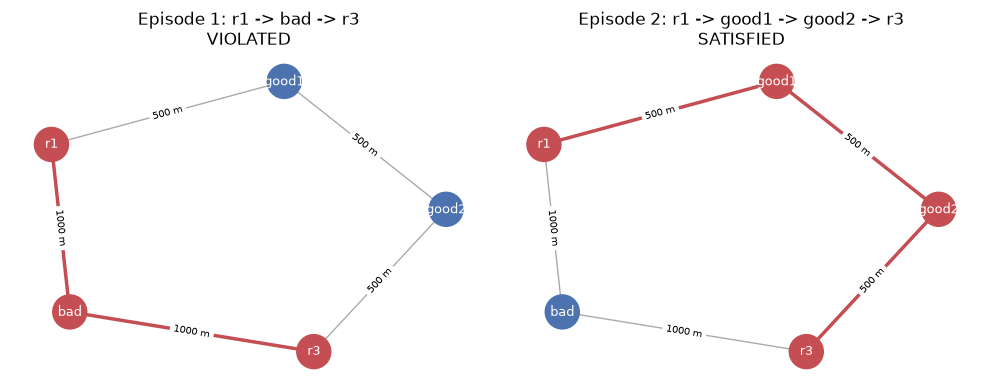

In [5]:
from ibqn.demos.visualization import draw_topology
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(demo.episodes), figsize=(5 * len(demo.episodes), 4))
if len(demo.episodes) == 1:
    axes = [axes]
for ax, episode in zip(axes, demo.episodes):
    draw_topology(
        spec, highlight_route=episode.route, ax=ax,
        title=f"Episode {episode.episode}: {' -> '.join(episode.route)}\n{episode.final_status.value}",
    )
fig.tight_layout()
plt.show()


In [6]:
from ibqn.intent.models import IntentStatus

assert demo.episodes[0].final_status == IntentStatus.VIOLATED
assert demo.episodes[-1].final_status == IntentStatus.SATISFIED
assert demo.episodes[0].route != demo.episodes[-1].route, "reconciliation must have actually picked a different route"

history_statuses = [t.to_status.value for t in demo.repository.get(intent.id).lifecycle.history]
print("Full lifecycle history across both episodes:")
print(" -> ".join(history_statuses))
assert "RECONCILING" in history_statuses, "the intent's history must show it went through RECONCILING between episodes"


Full lifecycle history across both episodes:
RECEIVED -> VALIDATED -> PLANNING -> PLANNED -> DEPLOYING -> ACTIVE -> VIOLATED -> RECONCILING -> PLANNING -> PLANNED -> DEPLOYING -> ACTIVE -> SATISFIED


## Interpretação
O episódio 1 (`ShortestHopCountRouting`) escolhe a rota de 2 saltos
(`bad`), que a alta atenuação torna lenta demais para entregar os pares
pedidos na janela - uma violação real, descoberta só depois de rodar a
simulação inteira (o planner v1 não estima throughput). A classificação
aponta a categoria `delivered_pairs`, e o episódio 2 troca apenas a
estratégia de roteamento (`LeastLossRouting`), numa `Timeline` totalmente
nova - o mesmo intent, a mesma topologia, mas uma decisão de HOW
diferente. O histórico de lifecycle acima mostra a sequência real:
`ACTIVE -> VIOLATED -> RECONCILING -> PLANNING -> ... -> ACTIVE -> SATISFIED`,
comprovando que o mesmo objeto de intent atravessou os dois episódios sem
perder sua história.

O episódio 2 tipicamente entrega muitos mais pares do que os 10 pedidos
(a tabela acima mostra o valor real desta execução) - isso não é um erro:
`requested_pairs` dimensiona o **pool de memórias** reservado
(`RSVPProtocol.schedule`), não um teto de entrega. Com uma rota de baixa
perda e tempo suficiente na janela, o SeQUeNCe continua gerando e
entregando pares novos até `end_time`, muito além do mínimo declarado. Uma
investigação mais aprofundada desse comportamento (e de uma eventual
métrica de "excesso de entrega") fica para a Fase H3.

## Limitações
- Isto é reconciliation **entre episódios** (nova `Timeline`), não
  reconfiguração dentro de uma reserva ativa - SeQUeNCe não expõe essa
  capacidade (`docs/sequence_code_analysis.md`).
- `reconcile()` só tenta uma vez: se o segundo episódio também violasse,
  o resultado seria retornado diretamente, sem uma terceira tentativa
  automática (`docs/assurance_design.md`).
- A escolha de qual estratégia usar no episódio 2 é feita por quem chama
  `reconcile()` (aqui, este notebook) - não há, nesta versão, uma lógica
  automática que escolha a nova estratégia a partir da categoria da
  violação.

## Conclusão
Reconciliation real demonstrada entre dois episódios genuínos - `VIOLATED`
seguido de `SATISFIED` - com todos os números (rota, pares entregues,
fidelidade, status) derivados da execução, nunca fixados manualmente.
